# Principal Balances dendrogram (PBA)

Cluster method of Martín-Fernández et al. (2018), *Advances in Principal
Balances for Compositional Data*, Math Geosci 50:273-298, Sect. 4.3.

- Parts clustered by **Ward on the variation matrix** `T_ij = Var(ln x_i/x_j)`.
- The tree is a sequential binary partition (SBP); its balances (Eq. 3) are the
  **principal balances**, ordered by variance. The full (top) balance carries
  the largest variance.

Set the filters in **Config**, run all cells: dendrogram + principal-balance
table are produced and the figure saved.

In [18]:
# Resolve project root so ./data paths work regardless of notebook location
import os
from pathlib import Path
_root = Path.cwd()
while not (_root / "data" / "geospatial").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
print("project root:", _root)

import os
import numpy as np
import geopandas as gpd
import composition_stats as coda
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
from scipy.spatial.distance import squareform

project root: /Users/antonkout/Documents/Doctorado/code/pastors


In [ ]:
dataset = "kenya"
# ─────────────────────────── CONFIG ───────────────────────────
GEOJSON_PATH = f"./data/geospatial/{dataset}_processed_closed.geojson"

PARTS         = ["Mg","Al","Si","P","K","Ca","Ti","Mn","Fe","Zn","Rb","Sr","Zr","Res"] #,"Ni","Cu"
EXCLUDE_PARTS = ["Res"]      # parts dropped before the analysis (closure residual)

# ── Row filters (None / [] / False to skip) ──
if dataset == "oman":
    INCLUDE_SITES = ["S4","S7","S10"]
    EXCLUDE_SITES = ["S11","S12"]
    TYPE_PREFIX   = "CORRAL"
elif dataset == "kenya":
    INCLUDE_SITES = ["E1","E2","E4","E7","E9"] #"E1","E2","E4","E7","E9"
    EXCLUDE_SITES = []
    TYPE_PREFIX   = "COR"
    
INCLUDE_TYPES    = None                # keep ONLY these exact Types
EXCLUDE_TYPES    = []                  # drop these Types
EXCLUDE_OUTLIERS = False               # drop is_outlier == True

# ── Plot ──
COLOR_FRAC = 0.6                       # colour threshold = COLOR_FRAC * max height
TITLE      = None
SAVE_PATH  = f"./output/{dataset}_pba_dendrogram.png"

In [20]:
# ─────────────────────────── LOAD + FILTER ───────────────────────────
g  = gpd.read_file(GEOJSON_PATH)
df = g.copy()
if INCLUDE_SITES:    df = df[df["Site"].astype(str).isin(INCLUDE_SITES)]
if EXCLUDE_SITES:    df = df[~df["Site"].astype(str).isin(EXCLUDE_SITES)]
if TYPE_PREFIX:      df = df[df["Type"].astype(str).str.startswith(TYPE_PREFIX)]
if INCLUDE_TYPES:    df = df[df["Type"].astype(str).isin(INCLUDE_TYPES)]
if EXCLUDE_TYPES:    df = df[~df["Type"].astype(str).isin(EXCLUDE_TYPES)]
if EXCLUDE_OUTLIERS and "is_outlier" in df.columns:
    df = df[~df["is_outlier"].astype(bool)]

PARTS_USE = [p for p in PARTS if p not in set(EXCLUDE_PARTS or [])]
if len(df) < 3:
    raise ValueError(f"Only {len(df)} rows after filtering.")

print(f"Rows: {len(df)} of {len(g)}  |  parts: {len(PARTS_USE)}")
print("Type:", df["Type"].astype(str).value_counts().to_dict())
print("Site:", df["Site"].astype(str).value_counts().to_dict())

P = df[PARTS_USE].astype(float).values
if (P <= 0).any():
    raise ValueError("Composition has non-positive values; impute zeros first.")

Rows: 63 of 1275  |  parts: 13
Type: {'CORAL': 42, 'CORRAL': 21}
Site: {'E1': 21, 'E4': 12, 'E9': 11, 'E7': 10, 'E2': 9}


In [21]:
# ─────────────────────────── PRINCIPAL BALANCES (PBA) ───────────────────────────
C    = coda.closure(P)
logC = np.log(C)
D    = len(PARTS_USE)

# Variation matrix -> Ward clustering of parts
T = np.zeros((D, D))
for i in range(D):
    for j in range(i + 1, D):
        T[i, j] = T[j, i] = np.var(logC[:, i] - logC[:, j], ddof=1)
Z = linkage(squareform(np.sqrt(T), checks=False), method="ward")

# SBP from the tree
def _leaves(n): return [n.id] if n.is_leaf() else _leaves(n.left) + _leaves(n.right)
SBP = []
def _visit(n):
    if n.is_leaf(): return
    L, R = _leaves(n.left), _leaves(n.right)
    row = np.zeros(D, int); row[L] = 1; row[R] = -1
    SBP.append(row); _visit(n.left); _visit(n.right)
_visit(to_tree(Z))
SBP = np.array(SBP)

# Balances [Eq. 3] and their variances -> principal balances
B = []
for row in SBP:
    nu, de = row == 1, row == -1
    r, s = nu.sum(), de.sum()
    B.append(np.sqrt(r*s/(r+s)) * (logC[:, nu].mean(1) - logC[:, de].mean(1)))
B = np.array(B).T
varb  = B.var(0, ddof=1)
total = varb.sum()
order = np.argsort(varb)[::-1]

print(f"Principal balances (Ward-cluster PBA)  |  total variance = {total:.3f}\n")
print(f"  {'PB':>3} {'+ group':<26} {'- group':<26} {'var':>7} {'%var':>6}")
for rank, k in enumerate(order, 1):
    plus  = "·".join(np.array(PARTS_USE)[SBP[k] == 1])
    minus = "·".join(np.array(PARTS_USE)[SBP[k] == -1])
    print(f"  {rank:>3} {plus:<26} {minus:<26} {varb[k]:>7.3f} {100*varb[k]/total:>5.1f}%")

Principal balances (Ward-cluster PBA)  |  total variance = 3.302

   PB + group                    - group                        var   %var
    1 Mg·P·K·Ca·Mn·Zn·Rb·Sr      Al·Si·Ti·Fe·Zr               1.806  54.7%
    2 Zr                         Al·Si·Ti·Fe                  0.820  24.8%
    3 Mg·Mn·Zn·Rb                P·K·Ca·Sr                    0.307   9.3%
    4 Ti·Fe                      Al·Si                        0.127   3.9%
    5 P                          K·Ca·Sr                      0.096   2.9%
    6 K                          Ca·Sr                        0.033   1.0%
    7 Mn·Rb                      Mg·Zn                        0.030   0.9%
    8 Al                         Si                           0.020   0.6%
    9 Ti                         Fe                           0.020   0.6%
   10 Mg                         Zn                           0.019   0.6%
   11 Mn                         Rb                           0.014   0.4%
   12 Ca                         S

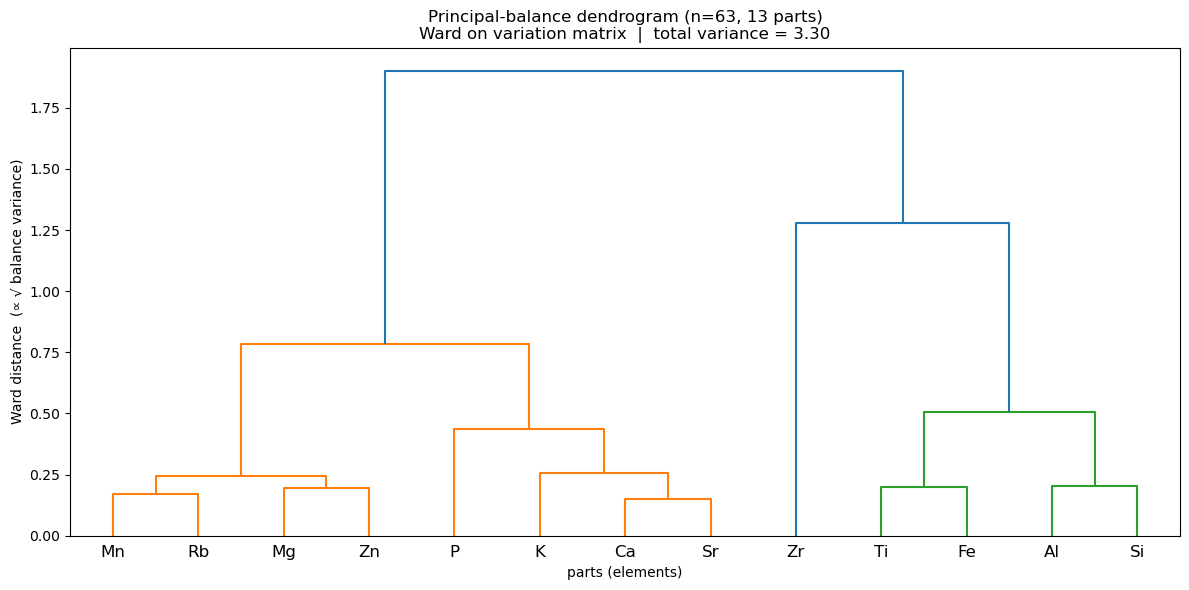

saved -> ./output/kenya_pba_dendrogram.png


In [22]:
# ─────────────────────────── DENDROGRAM ───────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(Z, labels=PARTS_USE, leaf_font_size=12,
           color_threshold=COLOR_FRAC * Z[:, 2].max(), ax=ax)
title = TITLE or f"Principal-balance dendrogram (n={len(df)}, {D} parts)"
ax.set_title(f"{title}\nWard on variation matrix  |  total variance = {total:.2f}", fontsize=12)
ax.set_ylabel("Ward distance  (∝ √ balance variance)")
ax.set_xlabel("parts (elements)")
plt.tight_layout()
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
plt.savefig(SAVE_PATH, dpi=140); plt.show()
print("saved ->", SAVE_PATH)

## Auto-search site combinations (maximise rank-1 principal balance)

Instead of hand-tuning `INCLUDE_SITES`, search Site subsets and rank them by the
top principal balance — the `var` / `%var` of PB #1 (e.g. the 0.248 / 35.2%).

- `objective='var'` ranks by absolute rank-1 variance; `'pct'` by its share of total.
- `method='exhaustive'` tries every subset (fine for Kenya's 5 sites);
  `'greedy'` does forward selection (use it for Oman's 16 sites).
- `min_samples` guards against tiny subsets that look variable just from few points.

The top row's `sites` is what to paste back into `INCLUDE_SITES`.

In [23]:
import sys, pandas as pd
sys.path.insert(0, "helpers")
from helpers.dendro_groups import search_site_combinations
pd.set_option("display.width", 220, "display.max_columns", 20)

ranked = search_site_combinations(
    GEOJSON_PATH,
    parts=PARTS, exclude_parts=EXCLUDE_PARTS,
    type_prefix=TYPE_PREFIX,
    objective="var",            # "var" (absolute) or "pct" (% of total variance)
    method="exhaustive",        # "greedy" if there are many sites (e.g. Oman)
    min_sites=2, max_sites=None,
    min_samples=10,             # skip combos with fewer than this many rows
    top_n=15,
)
cols = ["sites", "n_sites", "n_samples", "pb1_var", "pb1_pct", "total_variance"]
print(ranked[cols].to_string(index=False))

best = ranked.iloc[0]
print(f"\nBEST -> INCLUDE_SITES = {list(best['sites'])}")
print(f"  rank-1 PB: var={best['pb1_var']:.3f}  ({best['pb1_pct']:.1f}% of total)")
print(f"  balance:   {'·'.join(best['pb1_plus'])}  vs  {'·'.join(best['pb1_minus'])}")

           sites  n_sites  n_samples  pb1_var   pb1_pct  total_variance
        (E7, E9)        2         21 4.088645 58.815208        6.951681
        (E2, E7)        2         19 3.595784 64.227286        5.598530
        (E4, E7)        2         22 3.373687 65.817341        5.125833
    (E2, E7, E9)        3         30 3.123099 56.505862        5.527035
    (E4, E7, E9)        3         33 3.012168 56.627705        5.319248
    (E1, E7, E9)        3         42 2.484853 56.819994        4.373202
(E2, E4, E7, E9)        4         42 2.464551 55.916047        4.407591
    (E2, E4, E7)        3         31 2.393015 63.064377        3.794560
        (E1, E7)        2         31 2.367912 61.589865        3.844645
        (E2, E9)        2         20 2.349243 62.080013        3.784219
        (E4, E9)        2         23 2.216742 62.500848        3.546739
(E1, E2, E7, E9)        4         51 2.122000 55.772460        3.804746
(E1, E4, E7, E9)        4         54 2.065074 55.527407        3